## Logistic Regression for Admission Prediction

This project demonstrates the implementation of Logistic Regression using Python and Scikit-learn to predict student admission outcomes based on academic performance and work experience.

### What is Logistic Regression?

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. It predicts the probability of a categorical outcome using the sigmoid function.

### Applications
- Admission Prediction
- Spam Detection
- Disease Prediction
- Customer Churn Prediction

In [60]:
## Importing Required Libraries

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

### Creating the Dataset

The dataset contains:
- GMAT Score
- GPA
- Work Experience
- Admission Status

In [61]:

candidates = {'gmat': [780,750,690,710,680,730,690,720,740,690,610,690,710,680,770,610,580,650,540,590,620,600,550,550,570,670,660,580,650,660,640,620,660,660,680,650,670,580,590,690],
              'gpa': [4,3.9,3.3,3.7,3.9,3.7,2.3,3.3,3.3,1.7,2.7,3.7,3.7,3.3,3.3,3,2.7,3.7,2.7,2.3,3.3,2,2.3,2.7,3,3.3,3.7,2.3,3.7,3.3,3,2.7,4,3.3,3.3,2.3,2.7,3.3,1.7,3.7],
              'work_experience': [3,4,3,5,4,6,1,4,5,1,3,5,6,4,3,1,4,6,2,3,2,1,4,1,2,6,4,2,6,5,1,2,4,6,5,1,2,1,4,5],
              'admitted': [1,1,0,1,0,1,0,1,1,0,0,1,1,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,1,1,0,0,1,1,1,0,0,0,0,1]
              }

In [62]:
df = pd.DataFrame(candidates,columns= ['gmat', 'gpa','work_experience','admitted'])
print (df)

    gmat  gpa  work_experience  admitted
0    780  4.0                3         1
1    750  3.9                4         1
2    690  3.3                3         0
3    710  3.7                5         1
4    680  3.9                4         0
5    730  3.7                6         1
6    690  2.3                1         0
7    720  3.3                4         1
8    740  3.3                5         1
9    690  1.7                1         0
10   610  2.7                3         0
11   690  3.7                5         1
12   710  3.7                6         1
13   680  3.3                4         0
14   770  3.3                3         1
15   610  3.0                1         0
16   580  2.7                4         0
17   650  3.7                6         1
18   540  2.7                2         0
19   590  2.3                3         0
20   620  3.3                2         1
21   600  2.0                1         0
22   550  2.3                4         0
23   550  2.7   

In [63]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gmat             40 non-null     int64  
 1   gpa              40 non-null     float64
 2   work_experience  40 non-null     int64  
 3   admitted         40 non-null     int64  
dtypes: float64(1), int64(3)
memory usage: 1.4 KB


gmat               0
gpa                0
work_experience    0
admitted           0
dtype: int64

### Exploratory Data Analysis

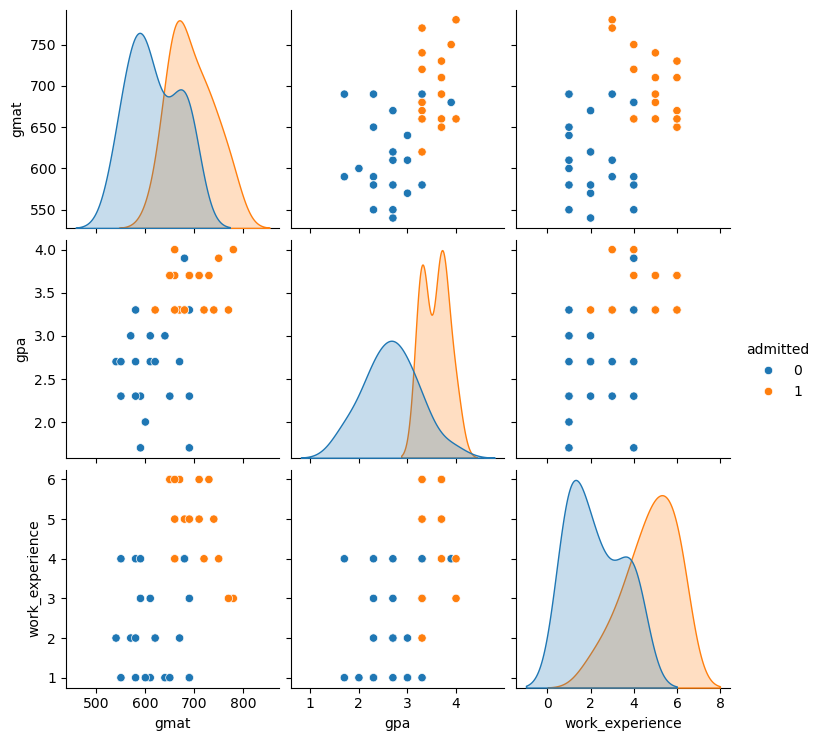

In [64]:
sn.pairplot(df, hue='admitted')
plt.show()

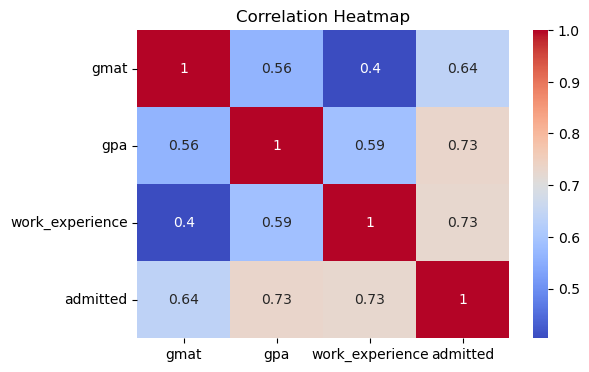

In [65]:
plt.figure(figsize=(6,4))
sn.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### Feature Selection

Independent variables are used to predict the target variable.

In [66]:
X = df[['gmat', 'gpa','work_experience']]
y = df['admitted']

### Splitting Dataset into Training and Testing Sets

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### Training the Logistic Regression Model

In [68]:
logistic_regression= LogisticRegression()
logistic_regression.fit(X_train,y_train)
y_pred=logistic_regression.predict(X_test)

### Making Predictions

In [69]:
print (X_test) #test dataset
print (y_pred) #predicted values

    gmat  gpa  work_experience
19   590  2.3                3
16   580  2.7                4
15   610  3.0                1
26   660  3.7                4
4    680  3.9                4
12   710  3.7                6
37   580  3.3                1
27   580  2.3                2
[0 0 0 1 1 1 0 0]


In [70]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head(10)

,Actual,Predicted
19,0,0
16,0,0
15,0,0
26,1,1
4,0,1
12,1,1
37,0,0
27,0,0


In [71]:
from sklearn.metrics import accuracy_score

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Accuracy Score: 0.875


In [72]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.83      0.91         6
           1       0.67      1.00      0.80         2

    accuracy                           0.88         8
   macro avg       0.83      0.92      0.85         8
weighted avg       0.92      0.88      0.88         8



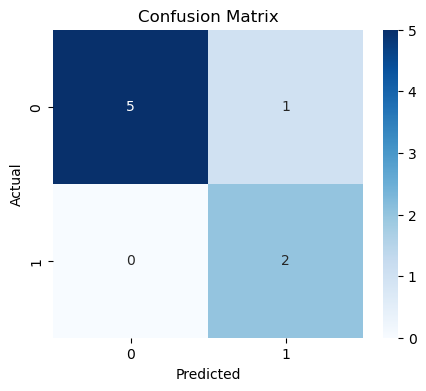

In [73]:
plt.figure(figsize=(5,4))

# Calculate the confusion matrix first
cm = metrics.confusion_matrix(y_test, y_pred)

# Plot it
sn.heatmap(cm,
           annot=True,
           fmt='d',
           cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


In [74]:
new_candidates = {'gmat': [590,740,680,610,710],
                  'gpa': [2,3.7,3.3,2.3,3],
                  'work_experience': [3,4,6,1,5]
                  }

df2 = pd.DataFrame(new_candidates,columns= ['gmat', 'gpa','work_experience'])

In [75]:
df2


,gmat,gpa,work_experience
0,590,2.0,3
1,740,3.7,4
2,680,3.3,6
3,610,2.3,1
4,710,3.0,5


And here is the complete code to get the prediction for the 5 new candidates.

In [76]:
y_pred=logistic_regression.predict(df2)
print (df2)
print (y_pred)

   gmat  gpa  work_experience
0   590  2.0                3
1   740  3.7                4
2   680  3.3                6
3   610  2.3                1
4   710  3.0                5
[0 1 1 0 1]


## Conclusion

This project successfully implemented Logistic Regression for admission prediction.

Key observations:
- GMAT score and GPA positively influence admission chances.
- Logistic Regression performed well for binary classification.
- Visualization and evaluation metrics helped assess model performance effectively.

Future Improvements:
- Use larger datasets
- Apply feature scaling
- Perform hyperparameter tuning
- Compare with other classification algorithms